## IMPLEMENTING A SIMPLIFIED ATTENTION MECHANISM
Consider the following input sentence, which has already been embedded into 3- dimensional vectors.

Sentence: **"Your journey starts with one step"**

We choose a small embedding dimension for illustration purposes to ensure it fits on the page without line breaks:

In [1]:
import torch

inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x1)
    [0.55, 0.87, 0.66], # journey (x2)
    [0.57, 0.85, 0.64], # starts (x3)
    [0.22, 0.58, 0.33], # with (x4)
    [0.77, 0.25, 0.10], # one (x5)
    [0.05, 0.80, 0.55]] # step (x6)
)

In [3]:
!pip3 install matplotlib

  Using cached matplotlib-3.11.0-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.0-cp313-cp313-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.2 MB 5.2 MB/s eta 0:00:02
   -------------- ------------------------- 2.6/7.2 MB 6.4 MB/s eta 0:00:01
   --------------------- ---------

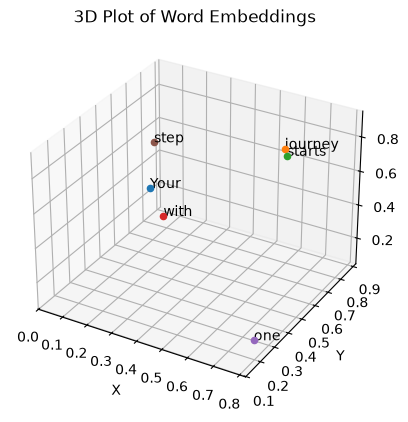

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step']

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

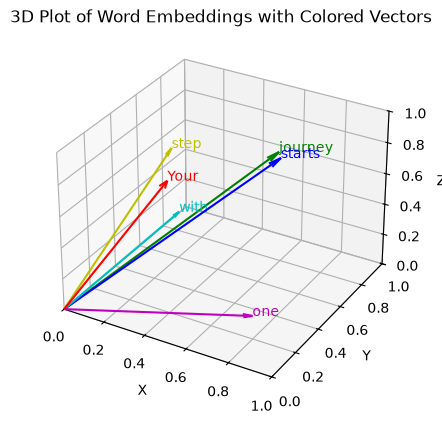

In [5]:
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()


Each row represents a word, and each column represents an embedding dimension

The second input token serves as the query

In [6]:
query = inputs[1]  # 2nd input token is the query

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # dot product (transpose not necessary here since they are 1-dim vectors)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In the next step, we normalize each of the attention scores that we computed previously.

The main goal behind the normalization is to obtain attention weights that sum up to 1.

This normalization is a convention that is useful for interpretation and for maintaining training stability in an LLM.

Here's a straightforward method for achieving this normalization step:

In [7]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)



In practice, it's more common and advisable to use the softmax function for normalization.

This approach is better at managing extreme values and offers more favorable gradient properties during training.

Below is a basic implementation of the softmax function for normalizing the attention scores:

In [8]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


As the output shows, the softmax function also meets the objective and normalizes the attention weights such that they sum to 1:

In addition, the softmax function ensures that the attention weights are always positive. This makes the output interpretable as probabilities or relative importance, where higher weights indicate greater importance.

Note that this naive softmax implementation (softmax_naive) may encounter numerical instability problems, such as overflow and underflow, when dealing with large or small input values.

Therefore, in practice, it's advisable to use the PyTorch implementation of softmax, which has been extensively optimized for performance:

In [9]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In this case, we can see that it yields the same results as our previous softmax_naive function.

The context vector z(2)is calculated as a weighted sum of all input vectors.

This involves multiplying each input vector by its corresponding attention weight:

In [10]:
query = inputs[1] # 2nd input token is the query

context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


Now, we can extend this computation to calculate attention weights and context vectors for all inputs.

First, we add an additional for-loop to compute the dot products for all pairs of inputs.

In [11]:
attn_scores = torch.empty(6, 6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Each element in the preceding tensor represents an attention score between each pair of inputs.

When computing the preceding attention score tensor, we used for-loops in Python.

However, for-loops are generally slow, and we can achieve the same results using matrix multiplication:

In [13]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


We now normalize each row so that the values in each row sum to 1:

In [25]:
attn_weights = torch.softmax(attn_scores, dim=1)
attn_weights_2 = torch.softmax(attn_scores, dim=-1) # we will be using this because this is the standard
attn_weights_3 = torch.softmax(attn_scores, dim=0)
print(attn_weights)
print()
print(attn_weights_2)
print()
print(attn_weights_3)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

tensor([[0.2098, 0.1385, 0.1390, 0.1435, 0.1526, 0.1385],
        [0.2006, 0.2379, 0.2369, 0.2074, 0.1958, 0.2184],
        [0.1981, 0.2333, 0.2326, 0.2046, 0.1975, 0.2128],
        [0.1242, 0.1240, 0.1242, 0.1462, 0.1367, 0.1420],
        [0.1220, 0.1082, 0.1108, 0.1263, 0.1879, 0.0988],
        [0

In the context of using PyTorch, the dim parameter in functions like torch.softmax specifies the dimension of the input tensor along which the function will be computed.

By setting dim=-1, we are instructing the softmax function to apply the normalization along the last dimension of the attn_scores tensor.

If attn_scores is a 2D tensor (for example, with a shape of [rows, columns]), dim=-1 will normalize across the columns so that the values in each row (summing over the column dimension) sum up to 1.

Let's briefly verify that the rows indeed all sum to 1:

In [26]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In the third and last step, we now use these attention weights to compute all context vectors via matrix multiplication

In [27]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


We can double-check that the code is correct by comparing the 2nd row with the context vector z(2) calculated previously

In [29]:
print("Previous 2nd context vector:", context_vec_2)
print("New 2nd context vector:     ", all_context_vecs[1])

Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])
New 2nd context vector:      tensor([0.4419, 0.6515, 0.5683])


Based on the result, we can see that the previously calculated context_vec_2 matches the second row in the previous tensor exactly